# 04 - Social Network Analysis

**Purpose:** build the social-exposure layer used in community-attention forecasting.

The Yelp friendship graph is static, so the project treats network measures as context and exposure, not causal influence. To avoid future leakage, all reviewer activity used to define active reviewers, edge weights, and community labels is limited to the same training period used later by the forecasting models: **2015-02 through 2017-12**.


## Objectives

- Use only the forecasting training-window reviews: **2015-02 through 2017-12**.
- Test active-reviewer thresholds: **2, 3, 5, 10, 20** training-window reviews.
- Keep nodes as active New Orleans reviewers from that training window.
- Keep edges as friendship links between active training-window reviewers.
- Weight edges by training-window behavioral overlap: shared New Orleans businesses and reviewed-category similarity.
- Export degree, weighted degree, PageRank, weighted PageRank, component, and community features.


## Graph Design

Construct a reviewer friendship graph for active reviewers using only the review activity available inside the forecasting training window.


In [ ]:
# Configure paths, thresholds, and plotting defaults.
from pathlib import Path
import json
from collections import Counter, defaultdict
from math import log1p

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "new_orleans"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "new_orleans"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "sna"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BUSINESSES_PATH = INTERIM_DIR / "businesses.jsonl"
REVIEWS_PATH = INTERIM_DIR / "reviews.jsonl"
USERS_PATH = INTERIM_DIR / "users.jsonl"
USER_NETWORK_FEATURES_PATH = PROCESSED_DIR / "user_network_features.csv"
GRAPH_SUMMARY_PATH = PROCESSED_DIR / "social_graph_summary.json"
THRESHOLD_SENSITIVITY_PATH = PROCESSED_DIR / "active_reviewer_threshold_sensitivity.csv"

# Match the target-month train split in 06_forecasting_models.ipynb.
SNA_TRAIN_START = pd.Period("2015-02", freq="M")
SNA_TRAIN_END = pd.Period("2017-12", freq="M")

THRESHOLD_CANDIDATES = [2, 3, 5, 10, 20]

EDGE_BASE_WEIGHT = 1.0
SHARED_BUSINESS_WEIGHT = 1.0
CATEGORY_OVERLAP_WEIGHT = 1.0

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})
print(PROJECT_ROOT)


C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp


In [ ]:
# Load New Orleans review and user extracts for graph construction.
def iter_jsonl(path):
    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            try:
                yield json.loads(line)
            except json.JSONDecodeError as exc:
                raise ValueError(f"Invalid JSON in {path} at line {line_number}") from exc

In [ ]:
# Identify active reviewers from the forecasting training window only.
business_categories = {}
for record in iter_jsonl(BUSINESSES_PATH):
    categories = record.get("categories") or ""
    business_categories[record["business_id"]] = {
        category.strip().casefold()
        for category in categories.split(",")
        if category.strip()
    }

user_review_counts = Counter()
user_business_sets = defaultdict(set)
user_category_sets = defaultdict(set)
sna_review_month_counts = Counter()
total_local_reviews = 0
training_window_reviews = 0

for record in iter_jsonl(REVIEWS_PATH):
    total_local_reviews += 1
    review_month = pd.Period(record["date"][:7], freq="M")
    if review_month < SNA_TRAIN_START or review_month > SNA_TRAIN_END:
        continue

    training_window_reviews += 1
    sna_review_month_counts[str(review_month)] += 1
    uid = record["user_id"]
    business_id = record["business_id"]
    user_review_counts[uid] += 1
    user_business_sets[uid].add(business_id)
    user_category_sets[uid].update(business_categories.get(business_id, set()))

all_reviewing_user_ids = set(user_review_counts)

print(f"SNA review window: {SNA_TRAIN_START} to {SNA_TRAIN_END}")
print(f"Training-window reviews used for SNA: {training_window_reviews:,} of {total_local_reviews:,} local reviews")
print(f"Reviewing users in SNA window: {len(all_reviewing_user_ids):,}")
print(f"Threshold candidates: {THRESHOLD_CANDIDATES}")


SNA review window: 2015-02 to 2017-12
Training-window reviews used for SNA: 206,862 of 635,521 local reviews
Reviewing users in SNA window: 92,329
Threshold candidates: [2, 3, 5, 10, 20]


## Weighted Network

Edges represent friendship links among New Orleans reviewers who were active in the forecasting training window. Edge weights summarize shared business/category context from that same window.


In [ ]:
# Build weighted friendship edges for active reviewers using shared local context.
def jaccard_similarity(left, right):
    if not left or not right:
        return 0.0
    return len(left & right) / len(left | right)


def local_friendship_edge(uid, fid):
    shared_business_count = len(user_business_sets[uid] & user_business_sets[fid])
    category_jaccard = jaccard_similarity(user_category_sets[uid], user_category_sets[fid])
    weight = (
        EDGE_BASE_WEIGHT
        + SHARED_BUSINESS_WEIGHT * log1p(shared_business_count)
        + CATEGORY_OVERLAP_WEIGHT * category_jaccard
    )
    return {
        "weight": weight,
        "shared_business_count": shared_business_count,
        "category_jaccard": category_jaccard,
    }


threshold_active_ids = {
    threshold: {uid for uid, count in user_review_counts.items() if count >= threshold}
    for threshold in THRESHOLD_CANDIDATES
}

threshold_graphs = {}
active_profile_counts = {}
for threshold, active_ids in threshold_active_ids.items():
    graph = nx.Graph()
    graph.add_nodes_from(active_ids)
    threshold_graphs[threshold] = graph
    active_profile_counts[threshold] = 0

matched_profiles = 0
for record in iter_jsonl(USERS_PATH):
    uid = record["user_id"]
    uid_review_count = user_review_counts.get(uid)
    if uid_review_count is None:
        continue
    matched_profiles += 1

    qualifying_thresholds = [threshold for threshold in THRESHOLD_CANDIDATES if uid_review_count >= threshold]
    if not qualifying_thresholds:
        continue
    for threshold in qualifying_thresholds:
        active_profile_counts[threshold] += 1

    friends = record.get("friends") or ""
    if friends == "None":
        continue
    for fid in friends.replace(", ", ",").split(","):
        fid = fid.strip()
        if not fid or uid >= fid:
            continue
        friend_review_count = user_review_counts.get(fid)
        if friend_review_count is None:
            continue

        max_shared_threshold = min(uid_review_count, friend_review_count)
        edge_attributes = local_friendship_edge(uid, fid)
        for threshold in THRESHOLD_CANDIDATES:
            if threshold <= max_shared_threshold:
                threshold_graphs[threshold].add_edge(uid, fid, **edge_attributes)


def graph_threshold_summary(threshold, graph):
    degree_values = [degree for _, degree in graph.degree()]
    weighted_degree_values = [degree for _, degree in graph.degree(weight="weight")]
    edge_weights = [data["weight"] for _, _, data in graph.edges(data=True)]
    shared_business_counts = [data["shared_business_count"] for _, _, data in graph.edges(data=True)]
    category_jaccards = [data["category_jaccard"] for _, _, data in graph.edges(data=True)]
    components = sorted(nx.connected_components(graph), key=len, reverse=True)
    largest_component_size = len(components[0]) if components else 0
    isolated_active_users = sum(1 for value in degree_values if value == 0)
    return {
        "active_review_threshold": threshold,
        "reviewing_users": len(all_reviewing_user_ids),
        "matched_user_profiles": matched_profiles,
        "active_users": len(threshold_active_ids[threshold]),
        "active_user_share": len(threshold_active_ids[threshold]) / len(all_reviewing_user_ids),
        "graph_nodes": graph.number_of_nodes(),
        "graph_edges": graph.number_of_edges(),
        "mean_edge_weight": pd.Series(edge_weights).mean() if edge_weights else 0,
        "mean_edge_shared_business_count": pd.Series(shared_business_counts).mean() if shared_business_counts else 0,
        "mean_edge_category_jaccard": pd.Series(category_jaccards).mean() if category_jaccards else 0,
        "connected_components": len(components),
        "largest_component_size": largest_component_size,
        "largest_component_share": largest_component_size / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "isolated_active_users": isolated_active_users,
        "isolated_active_user_share": isolated_active_users / graph.number_of_nodes() if graph.number_of_nodes() else 0,
        "median_friend_degree": pd.Series(degree_values).median() if degree_values else 0,
        "p90_friend_degree": pd.Series(degree_values).quantile(0.9) if degree_values else 0,
        "median_friend_weighted_degree": pd.Series(weighted_degree_values).median() if weighted_degree_values else 0,
        "p90_friend_weighted_degree": pd.Series(weighted_degree_values).quantile(0.9) if weighted_degree_values else 0,
    }


threshold_sensitivity = pd.DataFrame([
    graph_threshold_summary(threshold, threshold_graphs[threshold])
    for threshold in THRESHOLD_CANDIDATES
])
threshold_sensitivity.to_csv(THRESHOLD_SENSITIVITY_PATH, index=False)
threshold_sensitivity

,active_review_threshold,reviewing_users,matched_user_profiles,active_users,active_user_share,graph_nodes,graph_edges,mean_edge_weight,mean_edge_shared_business_count,mean_edge_category_jaccard,connected_components,largest_component_size,largest_component_share,isolated_active_users,isolated_active_user_share,median_friend_degree,p90_friend_degree,median_friend_weighted_degree,p90_friend_weighted_degree
0,2,92329,92329,34143,0.369797,34143,64381,1.422596,0.482083,0.205997,21321,12384,0.362710,20935,0.613156,0.0,7.0,0.000000,9.469196
1,3,92329,92329,18968,0.205439,18968,40840,1.552909,0.722821,0.236312,11087,7728,0.407423,10941,0.576814,0.0,9.0,0.000000,11.760870
2,5,92329,92329,8351,0.090448,8351,23563,1.740572,1.147265,0.260428,4254,4054,0.485451,4213,0.504490,0.0,12.0,0.000000,18.555580
3,10,92329,92329,2218,0.024023,2218,10606,2.100277,2.138789,0.283482,836,1370,0.617674,823,0.371055,1.0,25.0,2.599140,49.405552
4,20,92329,92329,579,0.006271,579,5284,2.501567,3.454580,0.317261,101,479,0.827288,100,0.172712,7.0,48.2,15.814599,116.146168


## Graph Choice

The working threshold is **5 training-window reviews**. It preserves a meaningful active-reviewer population while keeping the largest component large enough for centrality and community features.

Edge weights make friendships local to the New Orleans training window instead of treating every Yelp friendship or future review as equally informative.


In [ ]:
ACTIVE_REVIEW_THRESHOLD = 5

# Compare threshold choices to justify the active-reviewer graph design.
active_user_ids = threshold_active_ids[ACTIVE_REVIEW_THRESHOLD]
G = threshold_graphs[ACTIVE_REVIEW_THRESHOLD].copy()
active_profiles = active_profile_counts[ACTIVE_REVIEW_THRESHOLD]

print(f"Selected active-reviewer threshold: {ACTIVE_REVIEW_THRESHOLD}")
print(f"Matched user profiles: {matched_profiles:,}")
print(f"Active user profiles: {active_profiles:,}")
print(f"Graph nodes: {G.number_of_nodes():,}")
print(f"Graph edges: {G.number_of_edges():,}")

Selected active-reviewer threshold: 5
Matched user profiles: 92,329
Active user profiles: 8,351
Graph nodes: 8,351
Graph edges: 23,563


## Network Features

Compute centrality and community features from the training-window graph, then aggregate those fixed social-exposure features over recent reviewers for each later business-month.


In [ ]:
# Compute graph centrality, component, and community features for reviewers.
degree = dict(G.degree())
weighted_degree = dict(G.degree(weight="weight"))
components = sorted(nx.connected_components(G), key=len, reverse=True)
component_id_by_user = {}
component_size_by_user = {}
for cid, nodes in enumerate(components):
    for node in nodes:
        component_id_by_user[node] = cid
        component_size_by_user[node] = len(nodes)

pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight=None) if G.number_of_edges() else {node: 0.0 for node in G.nodes}
weighted_pagerank = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6, weight="weight") if G.number_of_edges() else {node: 0.0 for node in G.nodes}

edge_shared_business_sum = Counter()
edge_category_jaccard_sum = Counter()
for left, right, data in G.edges(data=True):
    edge_shared_business_sum[left] += data["shared_business_count"]
    edge_shared_business_sum[right] += data["shared_business_count"]
    edge_category_jaccard_sum[left] += data["category_jaccard"]
    edge_category_jaccard_sum[right] += data["category_jaccard"]

avg_friend_shared_businesses = {
    uid: edge_shared_business_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}
avg_friend_category_overlap = {
    uid: edge_category_jaccard_sum[uid] / degree[uid] if degree.get(uid, 0) else 0.0
    for uid in G.nodes
}

community_by_user = {node: -1 for node in G.nodes}
community_method = "not_computed"
if components and len(components[0]) >= 3:
    largest = G.subgraph(components[0]).copy()
    try:
        communities = nx.algorithms.community.louvain_communities(largest, seed=42, weight="weight")
        community_method = "weighted_louvain_largest_component"
        for community_id, nodes in enumerate(communities):
            for node in nodes:
                community_by_user[node] = community_id
    except Exception as exc:
        community_method = f"not_computed: {type(exc).__name__}: {exc}"

print(f"Connected components: {len(components):,}")
print(f"Largest component size: {len(components[0]) if components else 0:,}")
print(f"Isolated active users: {sum(1 for _, d in G.degree() if d == 0):,}")
print(f"Mean edge weight: {threshold_sensitivity.loc[threshold_sensitivity['active_review_threshold'] == ACTIVE_REVIEW_THRESHOLD, 'mean_edge_weight'].iloc[0]:.3f}")
print(f"Community method: {community_method}")

Connected components: 4,254
Largest component size: 4,054
Isolated active users: 4,213
Mean edge weight: 1.741
Community method: weighted_louvain_largest_component


In [ ]:
# Merge graph features back to the active reviewer table.
rows = []
for uid in all_reviewing_user_ids:
    rows.append({
        "user_id": uid,
        "subset_review_count": user_review_counts[uid],
        "active_reviewer": int(uid in active_user_ids),
        "friend_degree": degree.get(uid, 0),
        "friend_weighted_degree": weighted_degree.get(uid, 0.0),
        "pagerank": pagerank.get(uid, 0.0),
        "weighted_pagerank": weighted_pagerank.get(uid, 0.0),
        "avg_friend_shared_businesses": avg_friend_shared_businesses.get(uid, 0.0),
        "avg_friend_category_overlap": avg_friend_category_overlap.get(uid, 0.0),
        "component_id": component_id_by_user.get(uid, -1),
        "component_size": component_size_by_user.get(uid, 0),
        "community_id": community_by_user.get(uid, -1),
    })

user_network_features = pd.DataFrame(rows)
user_network_features.to_csv(USER_NETWORK_FEATURES_PATH, index=False)

selected_threshold_summary = threshold_sensitivity[
    threshold_sensitivity["active_review_threshold"] == ACTIVE_REVIEW_THRESHOLD
].iloc[0].to_dict()

summary = {
    "active_review_threshold": ACTIVE_REVIEW_THRESHOLD,
    "edge_weight_formula": "1 + log1p(shared_business_count) + category_jaccard",
    "sna_review_window_start": str(SNA_TRAIN_START),
    "sna_review_window_end": str(SNA_TRAIN_END),
    "sna_window_basis": "matches 06_forecasting_models target_month_str training split",
    "training_window_reviews": int(training_window_reviews),
    "total_local_reviews_available": int(total_local_reviews),
    "reviewing_users": len(all_reviewing_user_ids),
    "matched_user_profiles": matched_profiles,
    "active_users": len(active_user_ids),
    "graph_nodes": G.number_of_nodes(),
    "graph_edges": G.number_of_edges(),
    "mean_edge_weight": selected_threshold_summary["mean_edge_weight"],
    "mean_edge_shared_business_count": selected_threshold_summary["mean_edge_shared_business_count"],
    "mean_edge_category_jaccard": selected_threshold_summary["mean_edge_category_jaccard"],
    "connected_components": len(components),
    "largest_component_size": len(components[0]) if components else 0,
    "isolated_active_users": sum(1 for _, d in G.degree() if d == 0),
    "community_method": community_method,
    "communities_assigned": len(set(v for v in community_by_user.values() if v >= 0)),
    "threshold_sensitivity_output": str(THRESHOLD_SENSITIVITY_PATH),
    "output": str(USER_NETWORK_FEATURES_PATH),
}
with GRAPH_SUMMARY_PATH.open("w", encoding="utf-8") as file:
    json.dump(summary, file, indent=2)
    file.write("\n")
summary


{'active_review_threshold': 5,
 'edge_weight_formula': '1 + log1p(shared_business_count) + category_jaccard',
 'sna_review_window_start': '2015-02',
 'sna_review_window_end': '2017-12',
 'sna_window_basis': 'matches 06_forecasting_models target_month_str training split',
 'training_window_reviews': 206862,
 'total_local_reviews_available': 635521,
 'reviewing_users': 92329,
 'matched_user_profiles': 92329,
 'active_users': 8351,
 'graph_nodes': 8351,
 'graph_edges': 23563,
 'mean_edge_weight': 1.7405717853432006,
 'mean_edge_shared_business_count': 1.1472647795272248,
 'mean_edge_category_jaccard': 0.2604275800959453,
 'connected_components': 4254,
 'largest_component_size': 4054,
 'isolated_active_users': 4213,
 'community_method': 'weighted_louvain_largest_component',
 'communities_assigned': 32,
 'threshold_sensitivity_output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\active_reviewer_threshold_sensitivity.csv',
 'output': 'C:\

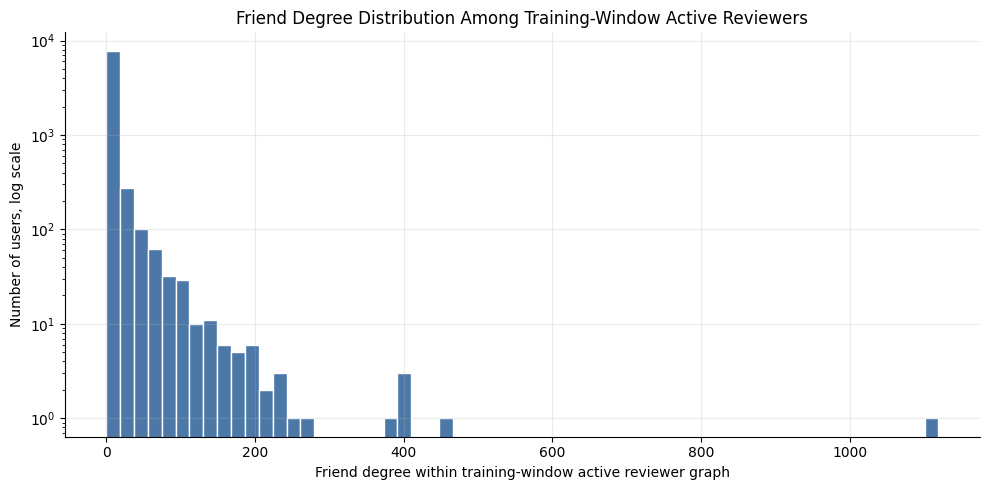

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\active_user_degree_distribution.png


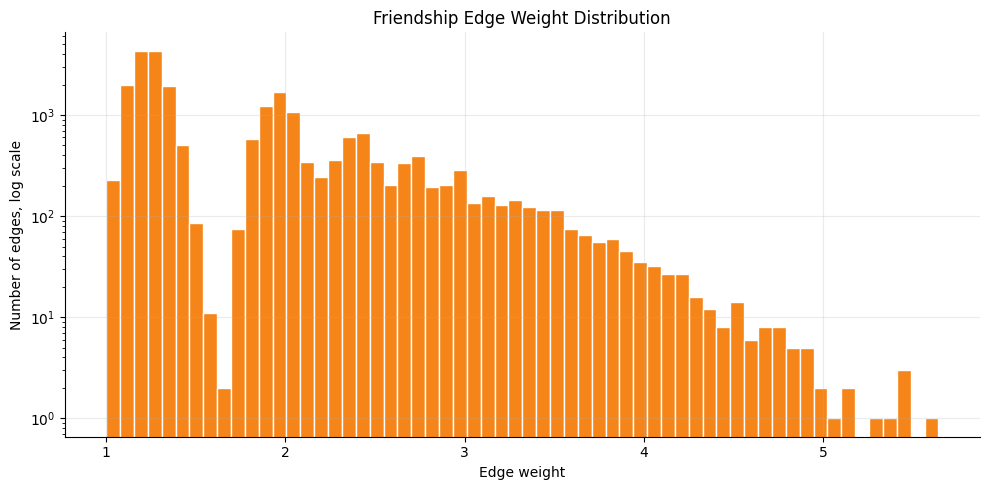

C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\friendship_edge_weight_distribution.png


{'active_review_threshold': 5,
 'edge_weight_formula': '1 + log1p(shared_business_count) + category_jaccard',
 'sna_review_window_start': '2015-02',
 'sna_review_window_end': '2017-12',
 'sna_window_basis': 'matches 06_forecasting_models target_month_str training split',
 'training_window_reviews': 206862,
 'total_local_reviews_available': 635521,
 'reviewing_users': 92329,
 'matched_user_profiles': 92329,
 'active_users': 8351,
 'graph_nodes': 8351,
 'graph_edges': 23563,
 'mean_edge_weight': 1.7405717853432006,
 'mean_edge_shared_business_count': 1.1472647795272248,
 'mean_edge_category_jaccard': 0.2604275800959453,
 'connected_components': 4254,
 'largest_component_size': 4054,
 'isolated_active_users': 4213,
 'community_method': 'weighted_louvain_largest_component',
 'communities_assigned': 32,
 'threshold_sensitivity_output': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\data\\processed\\new_orleans\\active_reviewer_threshold_sensitivity.csv',
 'output': 'C:\

In [ ]:
# Save SNA figures and graph summaries.
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(list(degree.values()), bins=60, color="#4C78A8", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friend Degree Distribution Among Training-Window Active Reviewers")
ax.set_xlabel("Friend degree within training-window active reviewer graph")
ax.set_ylabel("Number of users, log scale")
fig.tight_layout()
path = FIGURES_DIR / "active_user_degree_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
print(path)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist([data["weight"] for _, _, data in G.edges(data=True)], bins=60, color="#F58518", edgecolor="white")
ax.set_yscale("log")
ax.set_title("Friendship Edge Weight Distribution")
ax.set_xlabel("Edge weight")
ax.set_ylabel("Number of edges, log scale")
fig.tight_layout()
path = FIGURES_DIR / "friendship_edge_weight_distribution.png"
fig.savefig(path, dpi=160)
plt.show()
print(path)

summary


## Degree Distribution

The next plot treats the unweighted friendship degree as the training-window reviewer connectivity measure and plots the empirical degree frequency on log-log axes.


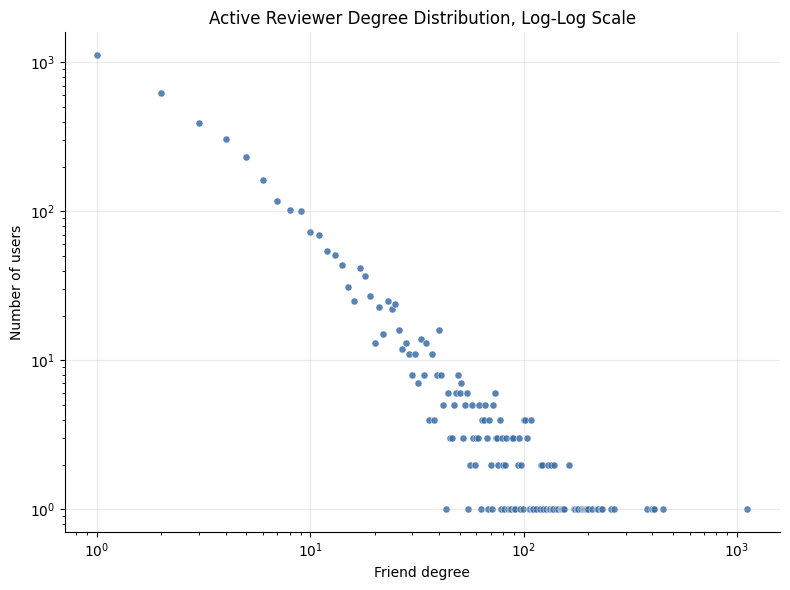

Saved: C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\degree_distribution_loglog.png
Isolated users: 4,213
Max degree: 1,119
Approximate log-log slope: -1.34; R^2: 0.86


{'nodes': 8351,
 'edges': 23563,
 'isolated_nodes': 4213,
 'max_degree': 1119,
 'median_degree': 0.0,
 'p90_degree': 12.0,
 'approx_loglog_slope': -1.3421798629647903,
 'approx_loglog_r2': 0.8602291356247658,
 'figure': 'C:\\Users\\mehdi\\OneDrive\\Documents\\community-forecasting-yelp\\outputs\\figures\\sna\\degree_distribution_loglog.png'}

In [ ]:
# Plot the active-reviewer degree distribution on log-log axes.
import numpy as np

review_count_in_sna_window = {
    node: data.get("review_count_in_sna_window", user_review_counts.get(node, 0))
    for node, data in G.nodes(data=True)
}
nx.set_node_attributes(G, review_count_in_sna_window, "review_count_in_sna_window")

degree_values = pd.Series(dict(G.degree()), name="degree")
degree_counts = degree_values.value_counts().sort_index()
positive_degree_counts = degree_counts[degree_counts.index > 0]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(
    positive_degree_counts.index,
    positive_degree_counts.values,
    s=26,
    color="#3B6EA8",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.4,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Active Reviewer Degree Distribution, Log-Log Scale")
ax.set_xlabel("Friend degree")
ax.set_ylabel("Number of users")
fig.tight_layout()
path = FIGURES_DIR / "degree_distribution_loglog.png"
fig.savefig(path, dpi=180)
plt.show()
plt.close(fig)

if len(positive_degree_counts) >= 3:
    log_degree = np.log10(positive_degree_counts.index.to_numpy(dtype=float))
    log_frequency = np.log10(positive_degree_counts.to_numpy(dtype=float))
    slope, intercept = np.polyfit(log_degree, log_frequency, 1)
    fitted = slope * log_degree + intercept
    ss_res = float(np.sum((log_frequency - fitted) ** 2))
    ss_tot = float(np.sum((log_frequency - log_frequency.mean()) ** 2))
    loglog_r2 = 1 - ss_res / ss_tot if ss_tot else np.nan
else:
    slope, loglog_r2 = np.nan, np.nan

degree_distribution_summary = {
    "nodes": int(G.number_of_nodes()),
    "edges": int(G.number_of_edges()),
    "isolated_nodes": int((degree_values == 0).sum()),
    "max_degree": int(degree_values.max()),
    "median_degree": float(degree_values.median()),
    "p90_degree": float(degree_values.quantile(0.90)),
    "approx_loglog_slope": float(slope) if not np.isnan(slope) else None,
    "approx_loglog_r2": float(loglog_r2) if not np.isnan(loglog_r2) else None,
    "figure": str(path),
}

print(f"Saved: {path}")
print(f"Isolated users: {degree_distribution_summary['isolated_nodes']:,}")
print(f"Max degree: {degree_distribution_summary['max_degree']:,}")
print(f"Approximate log-log slope: {slope:.2f}; R^2: {loglog_r2:.2f}")
degree_distribution_summary


The log-log plot shows a heavy-tailed degree distribution: most active New Orleans reviewers have few Yelp friendship ties inside the local graph, while a small set of users have many more connections.

## Hub Users

Degree centrality identifies highly connected reviewers, while approximate betweenness centrality identifies reviewers who sit on many shortest paths and may bridge otherwise separate parts of the training-window Yelp friendship graph.


In [ ]:
# Extract top reviewer hubs by degree centrality and approximate betweenness centrality.
from IPython.display import display

print("Computing approximate betweenness centrality with k=500 sampled source nodes...")
degree_centrality = nx.degree_centrality(G)
betweenness = nx.betweenness_centrality(G, k=500, seed=42)

hub_metrics = pd.DataFrame({
    "user_id": list(G.nodes()),
    "degree": [G.degree(node) for node in G.nodes()],
    "degree_centrality": [degree_centrality.get(node, 0.0) for node in G.nodes()],
    "betweenness": [betweenness.get(node, 0.0) for node in G.nodes()],
    "review_count_in_sna_window": [G.nodes[node].get("review_count_in_sna_window", user_review_counts.get(node, 0)) for node in G.nodes()],
})

top_degree_hubs = (
    hub_metrics
    .sort_values(["degree_centrality", "degree", "review_count_in_sna_window"], ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_degree_hubs.insert(0, "rank", range(1, len(top_degree_hubs) + 1))

top_betweenness_hubs = (
    hub_metrics
    .sort_values(["betweenness", "degree", "review_count_in_sna_window"], ascending=False)
    .head(20)
    .reset_index(drop=True)
)
top_betweenness_hubs.insert(0, "rank", range(1, len(top_betweenness_hubs) + 1))

hub_table_columns = ["rank", "user_id", "degree", "betweenness", "review_count_in_sna_window"]

print("Top 20 users by degree centrality")
display(top_degree_hubs[hub_table_columns])

print("Top 20 users by approximate betweenness centrality")
display(top_betweenness_hubs[hub_table_columns])


Computing approximate betweenness centrality with k=500 sampled source nodes...


Top 20 users by degree centrality


,rank,user_id,degree,betweenness,review_count_in_sna_window
0,1,5tXRxr4T24Awl7vjyCvIcQ,1119,0.072038,195
1,2,2jCrH48LDG4c3ja4CLh0qg,448,0.014216,19
2,3,Ase_kJIYuT6yOsqqVPuWUA,410,0.009715,103
3,4,9Qw7PWYwDSL3d2G4-sJ-Sw,408,0.007228,84
4,5,pCpZ6KF0vCOF3fyj9W8iMg,399,0.010940,117
5,6,0G-QF457q_0Z_jKqh6xWiA,378,0.014038,79
6,7,TE199OBEeJ4gmtRo-2kOfw,264,0.003169,29
7,8,ApjSaDZD9OeSqimHE9Qo0Q,256,0.013554,7
8,9,Xw7ZjaGfr0WNVt6s_5KZfA,233,0.002414,488
9,10,-TWmOCrqnTwfO5k04S3QrA,230,0.008119,9


Top 20 users by approximate betweenness centrality


,rank,user_id,degree,betweenness,review_count_in_sna_window
0,1,5tXRxr4T24Awl7vjyCvIcQ,1119,0.072038,195
1,2,2jCrH48LDG4c3ja4CLh0qg,448,0.014216,19
2,3,0G-QF457q_0Z_jKqh6xWiA,378,0.014038,79
3,4,ApjSaDZD9OeSqimHE9Qo0Q,256,0.013554,7
4,5,pCpZ6KF0vCOF3fyj9W8iMg,399,0.010940,117
5,6,Ase_kJIYuT6yOsqqVPuWUA,410,0.009715,103
6,7,ET8n-r7glWYqZhuR6GcdNw,139,0.009567,5
7,8,q1tg4-cLJWcy3HTEn9NlGQ,190,0.009558,6
8,9,-TWmOCrqnTwfO5k04S3QrA,230,0.008119,9
9,10,lMY8NBPyzlPbbu-KBYfD9A,210,0.007398,32


Degree hubs are the locally visible social connectors in the New Orleans Yelp reviewer community during the forecasting training window: they have many friendship ties to other active local reviewers, so their reviews can sit inside a broad social exposure neighborhood. Betweenness hubs are slightly different. They may not always have the highest raw degree, but they connect clusters that would otherwise be farther apart, making them useful bridges between reviewer circles. The `review_count_in_sna_window` column helps separate users who are both socially central and active in the training window from users whose importance comes mostly from friendship position.


## Louvain Community Detection

Reuse the weighted NetworkX Louvain communities computed on the largest connected component of the training-window graph.


In [ ]:
# Summarize weighted Louvain communities computed earlier with NetworkX.
louvain_partition = {node: community_id for node, community_id in community_by_user.items() if community_id >= 0}
nx.set_node_attributes(G, louvain_partition, "louvain_community")

louvain_community_sizes = (
    pd.Series(louvain_partition, name="community_id")
    .value_counts()
    .rename_axis("community_id")
    .reset_index(name="community_size")
    .sort_values("community_size", ascending=False)
    .reset_index(drop=True)
)

louvain_sets = [
    {node for node, label in louvain_partition.items() if label == community_id}
    for community_id in louvain_community_sizes["community_id"]
]
louvain_graph = G.subgraph(components[0]).copy() if components else nx.Graph()
louvain_modularity = (
    nx.algorithms.community.quality.modularity(louvain_graph, louvain_sets, weight="weight")
    if louvain_sets and louvain_graph.number_of_nodes()
    else 0.0
)

print(f"Communities found: {len(louvain_community_sizes):,}")
print("Size of the 5 largest communities:")
display(louvain_community_sizes.head(5))
print(f"Weighted modularity: {louvain_modularity:.3f}")

louvain_summary = {
    "communities_found": int(len(louvain_community_sizes)),
    "largest_community_sizes": louvain_community_sizes.head(5)["community_size"].astype(int).tolist(),
    "modularity": float(louvain_modularity),
}
louvain_summary


Communities found: 32
Size of the 5 largest communities:


,community_id,community_size
0,6,1708
1,30,989
2,9,626
3,1,194
4,28,177


Weighted modularity: 0.411


{'communities_found': 32,
 'largest_community_sizes': [1708, 989, 626, 194, 177],
 'modularity': 0.41074669296751254}

## Community Business Affinities

Map the largest training-window Louvain reviewer communities back to the businesses they reviewed most often inside the same SNA training window. This provides an interpretable business-level label for otherwise abstract network clusters.


In [ ]:
# For the five largest communities, count the training-window businesses reviewed most often by their users.
top_five_community_ids = louvain_community_sizes.head(5)["community_id"].tolist()
top_five_community_set = set(top_five_community_ids)
top_five_user_communities = {
    user_id: community_id
    for user_id, community_id in louvain_partition.items()
    if community_id in top_five_community_set
}

business_lookup = pd.DataFrame([
    {
        "business_id": record["business_id"],
        "name": record.get("name"),
        "categories": record.get("categories"),
    }
    for record in iter_jsonl(BUSINESSES_PATH)
])

community_business_counts = defaultdict(Counter)
for record in iter_jsonl(REVIEWS_PATH):
    review_month = pd.Period(record["date"][:7], freq="M")
    if review_month < SNA_TRAIN_START or review_month > SNA_TRAIN_END:
        continue
    community_id = top_five_user_communities.get(record["user_id"])
    if community_id is None:
        continue
    community_business_counts[community_id][record["business_id"]] += 1

community_size_lookup = louvain_community_sizes.set_index("community_id")["community_size"].to_dict()
community_business_rows = []
for community_id in top_five_community_ids:
    total_reviews = sum(community_business_counts[community_id].values())
    for rank, (business_id, review_count) in enumerate(community_business_counts[community_id].most_common(3), start=1):
        community_business_rows.append({
            "community_id": community_id,
            "community_size": int(community_size_lookup[community_id]),
            "rank": rank,
            "business_id": business_id,
            "community_business_reviews": int(review_count),
            "community_review_share": review_count / total_reviews if total_reviews else 0.0,
        })

top_community_businesses = (
    pd.DataFrame(community_business_rows)
    .merge(business_lookup, on="business_id", how="left")
    [[
        "community_id",
        "community_size",
        "rank",
        "business_id",
        "name",
        "community_business_reviews",
        "community_review_share",
        "categories",
    ]]
)

display(top_community_businesses)


,community_id,community_size,rank,business_id,name,community_business_reviews,community_review_share,categories
0,6,1708,1,_ab50qdWOk0DdB6XOrBitw,Acme Oyster House,273,0.017331,"Live/Raw Food, Seafood, Restaurants, Cajun/Creole"
1,6,1708,2,GBTPC53ZrG1ZBY3DT8Mbcw,Luke,190,0.012062,"German, Restaurants, Seafood, Cocktail Bars, F..."
2,6,1708,3,_C7QiQQc47AOEv4PE3Kong,Commander's Palace,181,0.011491,"French, Restaurants, Cocktail Bars, Nightlife,..."
3,30,989,1,8uF-bhJFgT4Tn6DTb27viA,District Donuts Sliders Brew,98,0.007958,"Food, Donuts, Burgers, American (Traditional),..."
4,30,989,2,2DTkzhmMpv5fIPKheePClA,Shaya,72,0.005847,"Mediterranean, Middle Eastern, Restaurants, De..."
5,30,989,3,Meww6RIE4cFL_kG0aRlbAA,Blue Oak BBQ,64,0.005197,"Chicken Wings, Restaurants, Nightlife, Barbequ..."
6,9,626,1,2DTkzhmMpv5fIPKheePClA,Shaya,79,0.005051,"Mediterranean, Middle Eastern, Restaurants, De..."
7,9,626,2,Meww6RIE4cFL_kG0aRlbAA,Blue Oak BBQ,66,0.004220,"Chicken Wings, Restaurants, Nightlife, Barbequ..."
8,9,626,3,8uF-bhJFgT4Tn6DTb27viA,District Donuts Sliders Brew,65,0.004156,"Food, Donuts, Burgers, American (Traditional),..."
9,1,194,1,VQcCL9PiNL_wkGf-uF3fjg,Royal House,23,0.012419,"American (New), Restaurants, Sandwiches, Seafo..."


## Sampled Community Graph

Draw a 1,000-node snowball sample from the largest connected component and color nodes by their training-window Louvain community label.


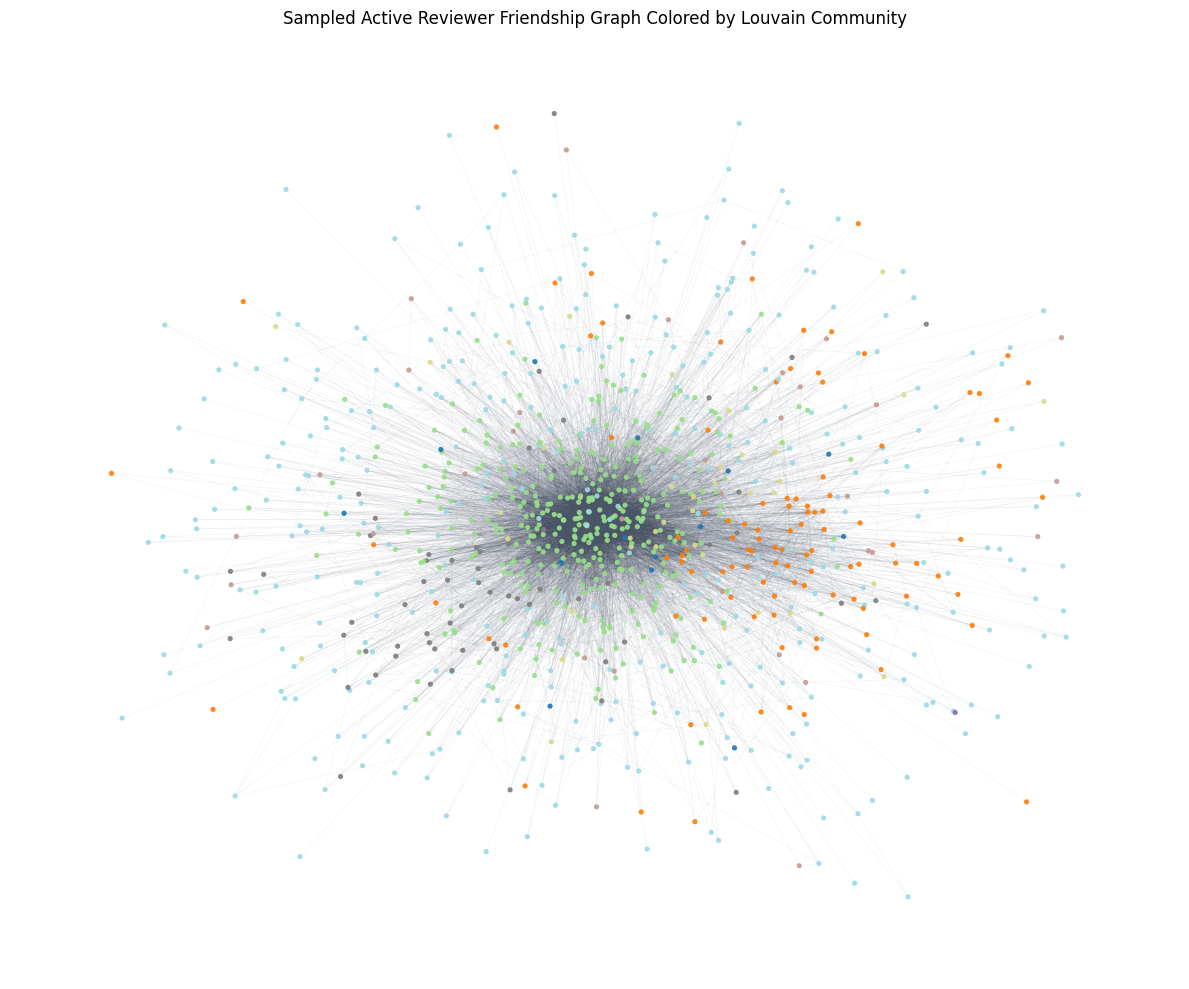

Sampled nodes: 1,000
Sampled edges: 11,575
Saved: C:\Users\mehdi\OneDrive\Documents\community-forecasting-yelp\outputs\figures\sna\community_graph.png


In [ ]:
# Visualise a sampled subgraph from the largest connected component with Louvain community colours.
from collections import deque

largest_component_nodes = set(components[0]) if components else set()
sample_size = min(1000, len(largest_component_nodes))

if sample_size:
    largest_component_subgraph = G.subgraph(largest_component_nodes)
    start_node = max(largest_component_nodes, key=lambda node: G.degree(node))
    sampled_nodes = []
    seen_nodes = {start_node}
    frontier = deque([start_node])

    while frontier and len(sampled_nodes) < sample_size:
        node = frontier.popleft()
        sampled_nodes.append(node)
        new_neighbors = [
            neighbor
            for neighbor in largest_component_subgraph.neighbors(node)
            if neighbor not in seen_nodes
        ]
        new_neighbors = sorted(new_neighbors, key=lambda neighbor: G.degree(neighbor), reverse=True)
        for neighbor in new_neighbors:
            seen_nodes.add(neighbor)
            frontier.append(neighbor)

    if len(sampled_nodes) < sample_size:
        remaining_nodes = [
            node
            for node in sorted(largest_component_nodes)
            if node not in set(sampled_nodes)
        ]
        sampled_nodes.extend(
            pd.Series(remaining_nodes)
            .sample(n=sample_size - len(sampled_nodes), random_state=42)
            .tolist()
        )

    sampled_subgraph = G.subgraph(sampled_nodes[:sample_size]).copy()
else:
    sampled_subgraph = G.copy()

sampled_communities = [louvain_partition.get(node, -1) for node in sampled_subgraph.nodes()]
community_color_lookup = {
    community_id: idx
    for idx, community_id in enumerate(sorted(set(sampled_communities)))
}
node_color_values = [community_color_lookup[community_id] for community_id in sampled_communities]

layout = nx.spring_layout(
    sampled_subgraph,
    seed=42,
    weight="weight",
    iterations=60,
    k=0.16,
)

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(
    sampled_subgraph,
    layout,
    ax=ax,
    alpha=0.08,
    width=0.4,
    edge_color="#4A5568",
)
nx.draw_networkx_nodes(
    sampled_subgraph,
    layout,
    ax=ax,
    node_size=14,
    node_color=node_color_values,
    cmap=plt.cm.tab20,
    linewidths=0,
    alpha=0.92,
)
ax.set_title("Sampled Active Reviewer Friendship Graph Colored by Louvain Community")
ax.set_axis_off()
fig.tight_layout()
community_graph_path = FIGURES_DIR / "community_graph.png"
fig.savefig(community_graph_path, dpi=180)
plt.show()
plt.close(fig)

print(f"Sampled nodes: {sampled_subgraph.number_of_nodes():,}")
print(f"Sampled edges: {sampled_subgraph.number_of_edges():,}")
print(f"Saved: {community_graph_path}")


## Community Structure Interpretation

The training-window Louvain communities reveal that the New Orleans Yelp reviewer graph is not one uniform audience. It contains dense local reviewer clusters that likely reflect overlapping friendship circles, shared dining and nightlife routines, tourism-oriented reviewers, and users who repeatedly review the same high-visibility local businesses during 2015-2017. The largest communities matter most for forecasting because they represent recurring pools of social attention: when several users from the same cluster review a business, the signal is less like isolated demand and more like activity spreading through a recognizable reviewer neighborhood. At the same time, the many isolated or tiny communities show the limit of the friendship graph: Yelp activity is partly social, but a large share of local reviewing still happens outside observed friendship ties.


## SNA Takeaways

- The selected graph is fit only on **2015-02 through 2017-12** reviews, matching the later forecasting training split.
- The active-reviewer threshold remains **5 training-window reviews**.
- All exported `user_network_features.csv` centrality, component, and community labels are therefore learned without validation, test, or post-2019 review activity.
- These features are best interpreted as social exposure signals for later business-month aggregation, not causal influence.


## SNA Limitations

- Yelp friendship links are static in the available dataset, so the graph cannot show when relationships formed.
- Network features measure social exposure among reviewers, not causal influence over future reviews.
- Sparse friendship coverage means some active reviewers have weak or missing network signal even when they are important locally.
- The train-only SNA graph intentionally ignores reviewers and shared-business relationships that appear only after 2017, so validation/test businesses may have weaker social coverage by design.
